# Business Analytics Lab Notebook



This notebook was developed as a practical lab exercise, it presents a structured analytics workflow that can be used for practice, demonstration, and report development.

It includes:

- business data generation
- data cleaning and exploratory data analysis
- KPI analysis
- customer segmentation
- sales prediction using machine learning
- business insights and conclusions

> The dataset used in this notebook is **synthetic**, allowing the analysis to run without external files.

## 1. Introduction

### Business Question
A retail company wants to understand:

1. which factors influence sales,
2. which customers create the highest value,
3. how it can predict future sales.

### Objective
To use Business Analytics techniques to turn data into decisions.

In [61]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
pd.set_option("display.max_columns", None)

## 2. Synthetic dataset creation
We will create a dataset with customer transactions for a retail business.

In [62]:
n = 3000

regions = ["Athens", "Thessaloniki", "Patra", "Heraklion", "Larisa"]
channels = ["Online", "Store"]
categories = ["Electronics", "Clothing", "Home", "Beauty", "Food"]
customer_types = ["New", "Returning", "Loyal"]

dates = pd.date_range("2024-01-01", periods=365, freq="D")

df = pd.DataFrame({
    "date": np.random.choice(dates, n),
    "region": np.random.choice(regions, n, p=[0.35, 0.2, 0.15, 0.15, 0.15]),
    "channel": np.random.choice(channels, n, p=[0.55, 0.45]),
    "category": np.random.choice(categories, n, p=[0.22, 0.2, 0.18, 0.15, 0.25]),
    "customer_type": np.random.choice(customer_types, n, p=[0.25, 0.45, 0.30]),
    "discount_pct": np.round(np.random.uniform(0, 0.35, n), 2),
    "marketing_spend": np.round(np.random.uniform(5, 200, n), 2),
    "units": np.random.randint(1, 8, n)
})

base_price_map = {
    "Electronics": 120,
    "Clothing": 45,
    "Home": 70,
    "Beauty": 35,
    "Food": 20
}

region_effect = {
    "Athens": 1.15,
    "Thessaloniki": 1.05,
    "Patra": 0.95,
    "Heraklion": 0.98,
    "Larisa": 0.92
}

channel_effect = {
    "Online": 1.08,
    "Store": 1.00
}

customer_effect = {
    "New": 0.90,
    "Returning": 1.00,
    "Loyal": 1.18
}

df["base_price"] = df["category"].map(base_price_map)

noise = np.random.normal(0, 18, n)

df["sales"] = (
    df["base_price"] * df["units"]
    * (1 - df["discount_pct"] * 0.55)
    * df["region"].map(region_effect)
    * df["channel"].map(channel_effect)
    * df["customer_type"].map(customer_effect)
    + 0.9 * df["marketing_spend"]
    + noise
)

df["sales"] = np.round(df["sales"].clip(lower=5), 2)

# Introducing a few missing values for realism
for col in ["region", "channel", "discount_pct", "marketing_spend"]:
    missing_idx = np.random.choice(df.index, size=int(0.02 * n), replace=False)
    df.loc[missing_idx, col] = np.nan

df.head()

,date,region,channel,category,customer_type,discount_pct,marketing_spend,units,base_price,sales
0,2024-04-12,Heraklion,Online,Food,Loyal,0.04,151.41,1,20,167.06
1,2024-12-14,Athens,Online,Beauty,Returning,0.16,48.45,7,35,358.33
2,2024-09-27,Larisa,Online,Food,Returning,0.18,198.89,2,20,205.74
3,2024-04-16,Thessaloniki,Online,Electronics,New,0.05,37.73,4,120,521.07
4,2024-03-12,Athens,Online,Clothing,Loyal,0.34,158.81,6,45,474.83


## 3. Quick data overview

In [63]:
print("Dataset shape:", df.shape)
print("\nVariable types:")
display(df.dtypes)

print("\nNumber of missing values:")
display(df.isna().sum())

display(df.describe(include="all"))

Dataset shape: (3000, 10)

Variable types:


date               datetime64[ns]
region                     object
channel                    object
category                   object
customer_type              object
discount_pct              float64
marketing_spend           float64
units                       int32
base_price                  int64
sales                     float64
dtype: object


Number of missing values:


date                0
region             60
channel            60
category            0
customer_type       0
discount_pct       60
marketing_spend    60
units               0
base_price          0
sales               0
dtype: int64

C:\Users\ioann\AppData\Local\Temp/ipykernel_28552/1908991281.py:8: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(df.describe(include="all"))


,date,region,channel,category,customer_type,discount_pct,marketing_spend,units,base_price,sales
count,3000,2940,2940,3000,3000,2940.000000,2940.000000,3000.000000,3000.000000,3000.000000
unique,365,5,2,5,3,NaN,NaN,NaN,NaN,NaN
top,2024-01-12 00:00:00,Athens,Online,Food,Returning,NaN,NaN,NaN,NaN,NaN
freq,17,1019,1616,730,1373,NaN,NaN,NaN,NaN,NaN
first,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,2024-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.175493,100.766588,4.028000,58.408333,328.024327
std,NaN,NaN,NaN,NaN,NaN,0.099933,56.370261,1.985916,36.579196,214.719884
min,NaN,NaN,NaN,NaN,NaN,0.000000,5.000000,1.000000,20.000000,5.000000
25%,NaN,NaN,NaN,NaN,NaN,0.090000,51.195000,2.000000,35.000000,179.017500


## 4. Data cleaning and feature engineering

In [64]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["day_of_week"] = df["date"].dt.day_name()

# For the KPIs, we keep a cleaned copy
df_clean = df.copy()

# Simple imputations for descriptive analysis
df_clean["region"] = df_clean["region"].fillna(df_clean["region"].mode()[0])
df_clean["channel"] = df_clean["channel"].fillna(df_clean["channel"].mode()[0])
df_clean["discount_pct"] = df_clean["discount_pct"].fillna(df_clean["discount_pct"].median())
df_clean["marketing_spend"] = df_clean["marketing_spend"].fillna(df_clean["marketing_spend"].median())

df_clean.head()

,date,region,channel,category,customer_type,discount_pct,marketing_spend,units,base_price,sales,month,quarter,day_of_week
0,2024-04-12,Heraklion,Online,Food,Loyal,0.04,151.41,1,20,167.06,4,2,Friday
1,2024-12-14,Athens,Online,Beauty,Returning,0.16,48.45,7,35,358.33,12,4,Saturday
2,2024-09-27,Larisa,Online,Food,Returning,0.18,198.89,2,20,205.74,9,3,Friday
3,2024-04-16,Thessaloniki,Online,Electronics,New,0.05,37.73,4,120,521.07,4,2,Tuesday
4,2024-03-12,Athens,Online,Clothing,Loyal,0.34,158.81,6,45,474.83,3,1,Tuesday


## 5. KPIs (Key Performance Indicators)

In [65]:
total_sales = df_clean["sales"].sum()
avg_order_value = df_clean["sales"].mean()
total_units = df_clean["units"].sum()
avg_discount = df_clean["discount_pct"].mean()
avg_marketing = df_clean["marketing_spend"].mean()

kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Average Order Value",
        "Total Units Sold",
        "Average Discount",
        "Average Marketing Spend"
    ],
    "Value": [
        round(total_sales, 2),
        round(avg_order_value, 2),
        int(total_units),
        round(avg_discount, 3),
        round(avg_marketing, 2)
    ]
})

kpis

,KPI,Value
0,Total Sales,984072.980
1,Average Order Value,328.020
2,Total Units Sold,12084.000
3,Average Discount,0.175
4,Average Marketing Spend,100.760


## 6. Exploratory Data Analysis (EDA)

In [66]:
sales_by_region = df_clean.groupby("region", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
sales_by_category = df_clean.groupby("category", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
sales_by_channel = df_clean.groupby("channel", as_index=False)["sales"].sum().sort_values("sales", ascending=False)

display(sales_by_region)
display(sales_by_category)
display(sales_by_channel)

,region,sales
0,Athens,380097.80
4,Thessaloniki,183431.29
1,Heraklion,145879.87
2,Larisa,139372.42
3,Patra,135291.60


,category,sales
2,Electronics,383406.54
4,Home,204738.17
1,Clothing,161468.02
3,Food,127252.88
0,Beauty,107207.37


,channel,sales
0,Online,564500.93
1,Store,419572.05


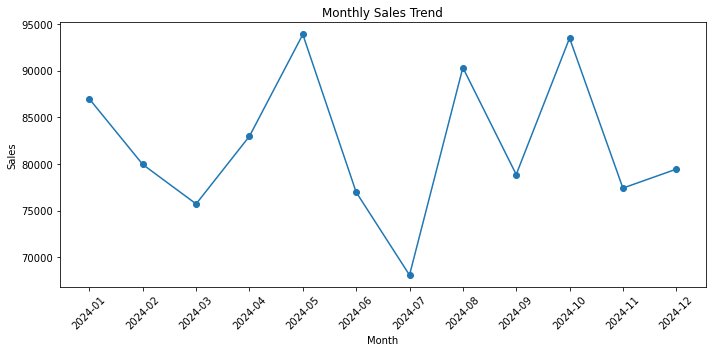

In [67]:
monthly_sales = (
    df_clean.groupby(df_clean["date"].dt.to_period("M"))["sales"]
    .sum()
    .reset_index()
)
monthly_sales["date"] = monthly_sales["date"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["date"], monthly_sales["sales"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

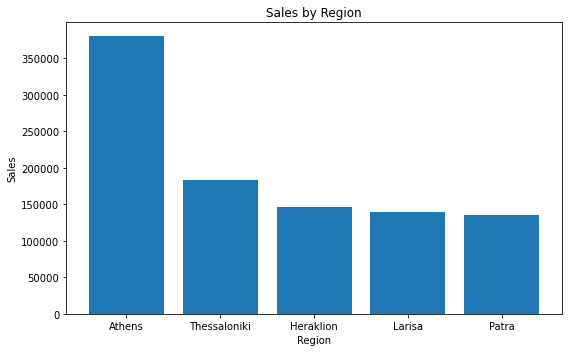

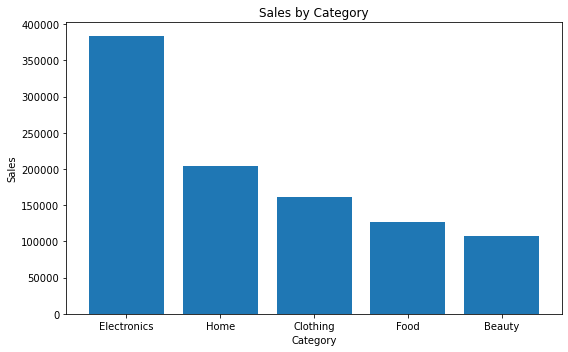

In [68]:
plt.figure(figsize=(8, 5))
plt.bar(sales_by_region["region"], sales_by_region["sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(sales_by_category["category"], sales_by_category["sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [69]:
pivot_ct = pd.pivot_table(
    df_clean,
    values="sales",
    index="customer_type",
    columns="channel",
    aggfunc="mean"
)

pivot_ct

channel,Online,Store
customer_type,,
Loyal,357.464980,354.342630
New,327.462985,279.889969
Returning,328.569455,311.387993


## 7. Customer Segmentation

We will perform a simple segmentation based on:

- **Frequency**: number of transactions
- **Monetary**: total sales value

Since we do not have a unique customer ID from a real system, we will generate synthetic customer IDs.

In [70]:
n_customers = 400
df_clean["customer_id"] = np.random.choice([f"C{str(i).zfill(3)}" for i in range(1, n_customers + 1)], len(df_clean))

customer_summary = (
    df_clean.groupby("customer_id")
    .agg(
        frequency=("sales", "count"),
        monetary=("sales", "sum"),
        avg_order_value=("sales", "mean")
    )
    .reset_index()
)

# Segmentation using quantiles
freq_q = customer_summary["frequency"].quantile([0.33, 0.66]).values
mon_q = customer_summary["monetary"].quantile([0.33, 0.66]).values

def label_segment(row):
    if row["frequency"] >= freq_q[1] and row["monetary"] >= mon_q[1]:
        return "High Value"
    elif row["frequency"] >= freq_q[0] and row["monetary"] >= mon_q[0]:
        return "Medium Value"
    else:
        return "Low Value"

customer_summary["segment"] = customer_summary.apply(label_segment, axis=1)
customer_summary.head()

,customer_id,frequency,monetary,avg_order_value,segment
0,C001,4,1898.57,474.642500,Low Value
1,C002,6,2448.27,408.045000,Medium Value
2,C003,8,3131.75,391.468750,High Value
3,C004,8,2935.06,366.882500,High Value
4,C005,6,1356.40,226.066667,Low Value


In [71]:
segment_stats = (
    customer_summary.groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_order_value=("avg_order_value", "mean")
    )
    .reset_index()
)

segment_stats

,segment,customers,avg_frequency,avg_monetary,avg_order_value
0,High Value,115,10.582609,3666.248435,350.718389
1,Low Value,144,5.027778,1432.847153,295.018542
2,Medium Value,141,7.510638,2525.705106,345.247484


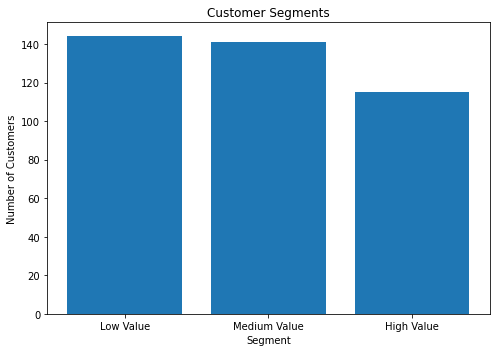

In [72]:
segment_counts = customer_summary["segment"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 8. Predictive Analytics – Sales Prediction

We will build a model that predicts the **sales** variable.

In [73]:
model_df = df.copy()

X = model_df.drop(columns=["sales", "date"])
y = model_df["sales"]

categorical_features = ["region", "channel", "category", "customer_type", "day_of_week"]
numeric_features = ["discount_pct", "marketing_spend", "units", "base_price", "month", "quarter"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

metrics

,Metric,Value
0,MAE,28.097799
1,RMSE,37.987694
2,R²,0.970551


In [74]:
results = pd.DataFrame({
    "actual_sales": y_test.values,
    "predicted_sales": preds
})

results["error"] = results["actual_sales"] - results["predicted_sales"]
results.head(10)

,actual_sales,predicted_sales,error
0,528.94,469.308457,59.631543
1,462.19,428.485766,33.704234
2,262.11,282.346328,-20.236328
3,358.96,364.421560,-5.461560
4,349.42,327.066598,22.353402
5,400.70,385.402594,15.297406
6,293.62,253.230469,40.389531
7,300.34,314.014086,-13.674086
8,184.58,203.969526,-19.389526
9,464.17,419.280655,44.889345


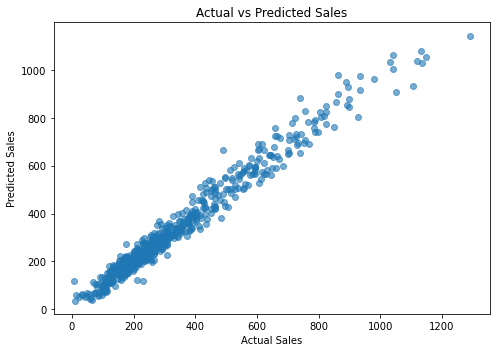

In [75]:
plt.figure(figsize=(7, 5))
plt.scatter(results["actual_sales"], results["predicted_sales"], alpha=0.6)
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

## 9. Business Insights

Example interpretation of the results:

- The **regions with the highest sales** are critical targets for marketing and inventory investment.
- The **product categories** that contribute the most to total sales can become strategic priorities.
- **High Value** customers require retention strategies such as loyalty programs and personalized offers.
- The predictive model can support:
  - demand forecasting,
  - budget allocation,
  - campaign planning.

## 10. Conclusion

The Business Analytics workflow followed in this analysis includes:

1. data collection / generation  
2. data cleaning and transformation  
3. KPI analysis  
4. segmentation  
5. predictive modeling  
6. business decision-making  

This notebook can be easily extended with:

- classification models (e.g., churn prediction),
- time series forecasting,
- dashboard development with Power BI or Tableau,
- A/B testing analysis.

## 11. Optional Extensions

You can add:

- more features,
- comparison of multiple models,
- feature importance analysis,
- profitability analysis instead of focusing only on sales,
- a markdown cell with your own reflections on the course.